# N1 · roofline 模型: compute-bound vs memory-bound

> 复用 `src/roofline.py` + `capstone_roofline_zoo.py` · 算不同算子的算术强度, 判断它撞的是算力墙还是带宽墙。
> roofline 是 GPU 性能分析的核心工具 (接本专题讲义)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import roofline as rf
import capstone_roofline_zoo as zoo
print('gpu-architecture src 就绪')

gpu-architecture src 就绪


## 1. 算子动物园: 各算子是 compute-bound 还是 memory-bound

In [2]:
results = zoo.run()
print(f"{'算子':<22} {'强度(FLOP/B)':>12} {'利用率%':>8} {'瓶颈':>10}")
for r in results[:12]:
    print(f"{str(r['op']):<22} {r['ai']:>12.1f} {r['utilization_pct']:>8.1f} {str(r['bound_by']):>10}")

算子                       强度(FLOP/B)     利用率%         瓶颈
gemv-1x4k-4k                    1.0      0.7     memory
gemm-2k-2k-2k                 682.7    100.0    compute
gemm-8k-8k-8k                2730.7    100.0    compute
attn-b1-h32-s2k               204.8    100.0    compute
attn-b1-h32-s32k              252.1    100.0    compute
layernorm-4k-4k                 2.0      1.3     memory
layernorm-4k-8k                 2.0      1.3     memory
gemm-4k-4k-128                120.5     78.7     memory
gemm-128-4k-4k                120.5     78.7     memory
gemm-32k-32k-32k            10922.7    100.0    compute
gemv-1x4k-4k                    1.0      0.3     memory
gemm-2k-2k-2k                 682.7    100.0    compute


## 2. roofline 图 (算术强度 vs 可达性能)

summary: {'total': 40, 'memory_bound': 25, 'compute_bound': 15, 'avg_util_pct': 59.2, 'h100_big_gemm_util': 100.0}


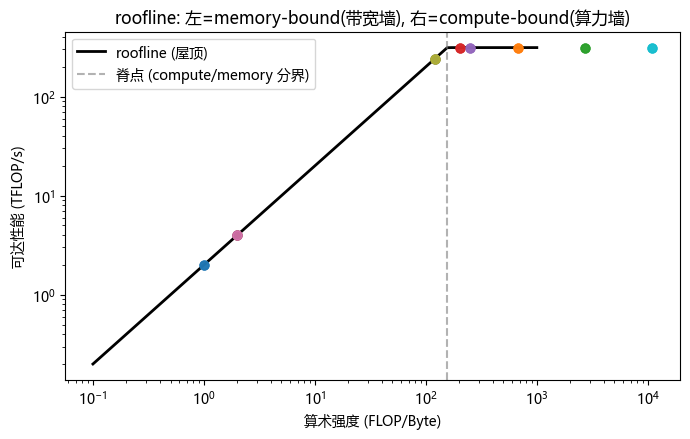

→ 算子落在脊点左侧=memory-bound(优化带宽/融合), 右侧=compute-bound(优化算力/tensor core)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
try:
    s = zoo.summarize(results)
    print('summary:', s)
except Exception as e:
    print('summarize:', e)
# 画 roofline: 性能 = min(峰值算力, 带宽 × 算术强度)
peak_flops = 312e12; bw = 2e12   # 示意: ~A100 bf16
ai = np.logspace(-1, 3, 100)
perf = np.minimum(peak_flops, bw*ai)
plt.figure(figsize=(7,4.5))
plt.loglog(ai, perf/1e12, 'k-', lw=2, label='roofline (屋顶)')
plt.axvline(peak_flops/bw, ls='--', c='gray', alpha=0.6, label='脊点 (compute/memory 分界)')
for r in results:
    a = r.get('ai', None)
    if a: plt.scatter([a],[min(peak_flops, bw*a)/1e12], s=40, alpha=0.6, zorder=5)
plt.xlabel('算术强度 (FLOP/Byte)'); plt.ylabel('可达性能 (TFLOP/s)')
plt.title('roofline: 左=memory-bound(带宽墙), 右=compute-bound(算力墙)'); plt.legend(); plt.tight_layout(); plt.show()
print('→ 算子落在脊点左侧=memory-bound(优化带宽/融合), 右侧=compute-bound(优化算力/tensor core)。')